In [1]:
import os
import sys

for _ in range(4):
    os.chdir("..")

# os.getcwd()

In [2]:
RANDOM_SEED = 42
PROJECT_PATH = './projects/main'
SOURCE_FILENAME = 'dayuses.csv'

### Imports

In [3]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import scipy.stats as ss
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor, CatBoostClassifier, monoforest
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [4]:
%run projects/scripts/reload

### Source file

The source CSV contains one row per (user_id, event_date) with columns:
   - search/cat: binary flags for search/catalog activity
   - has_search_to_cart/ord, has_cat_to_cart/ord: conversion flags
   - search_to_cart/ord, cat_to_cart/ord: conversion counts
   - gmv_search, gmv_cat, gmv: monetary values
   - to_cart, to_ord: total add-to-cart / order counts
   - searches: number of search queries
   
 Data spans Jan 1 — Oct 31, 2025 (~49.4M rows).

In [5]:
pd.read_csv(PROJECT_PATH + '/source/' + SOURCE_FILENAME)

,event_date,search,cat,has_search_to_cart,has_search_to_ord,has_cat_to_cart,has_cat_to_ord,search_to_cart,search_to_ord,cat_to_cart,cat_to_ord,gmv_search,gmv_cat,to_cart,to_ord,gmv,searches,user_id
0,2025-01-01,1,1,1,0,1,0,1,0,1,0,0.000000,0.0,2,0,0.000000,3,704555
1,2025-01-01,1,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,2,588098
2,2025-01-01,1,1,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,1,257110
3,2025-01-01,1,0,1,1,0,0,2,2,0,0,53.693340,0.0,2,2,53.693340,2,249640
4,2025-01-01,1,0,1,1,0,0,3,3,0,0,723.934309,0.0,3,3,723.934309,7,151379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49414699,2025-10-31,0,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,0,259179
49414700,2025-10-31,1,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,7,365839
49414701,2025-10-31,0,1,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,0,131933
49414702,2025-10-31,1,0,1,0,0,0,1,0,0,0,0.000000,0.0,1,0,0.000000,1,671156


# 0. Data Loading and Processing

\- Define required columns for validation.

These are the event-level metrics that SessionProcessor checks on load.

In [6]:
required_columns = [
    'search', 'cat',
    'has_search_to_cart', 'has_search_to_ord',
    'has_cat_to_cart', 'has_cat_to_ord',
    'search_to_cart', 'search_to_ord',
    'cat_to_cart', 'cat_to_ord',
    'gmv_search', 'gmv_cat',
    'to_cart', 'to_ord', 'gmv', 'searches'
]

\- Initialize and load SessionProcessor

In [7]:
USER_ID_COL = 'user_id'
session_processor_kwargs = {
    'timestamp_col': 'event_date',
    'user_id_col': USER_ID_COL,
    'required_columns': required_columns # optional check
}
session_processor = SessionProcessor(**session_processor_kwargs)
session_processor.load(file_path=PROJECT_PATH + '/source/' + SOURCE_FILENAME)

,event_date,search,cat,has_search_to_cart,has_search_to_ord,has_cat_to_cart,has_cat_to_ord,search_to_cart,search_to_ord,cat_to_cart,cat_to_ord,gmv_search,gmv_cat,to_cart,to_ord,gmv,searches,user_id
0,2025-01-01,1,1,1,0,1,0,1,0,1,0,0.000000,0.0,2,0,0.000000,3,704555
70093,2025-01-01,1,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,1,226882
70092,2025-01-01,1,1,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,2,198016
70091,2025-01-01,1,1,1,1,0,0,1,1,0,0,57.034206,0.0,1,1,57.034206,4,453919
70090,2025-01-01,0,1,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,0,10681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49283909,2025-10-31,1,1,1,1,0,0,2,2,0,0,75.776274,0.0,2,2,75.776274,4,530266
49283910,2025-10-31,1,0,1,0,0,0,1,0,0,0,0.000000,0.0,1,0,0.000000,1,475856
49283911,2025-10-31,0,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,0,517508
49283902,2025-10-31,1,0,1,1,0,0,1,1,0,0,15.485823,0.0,1,1,15.485823,4,280717


\- Total unique users in the dataset

Confirms we have ~830K unique users.

In [8]:
session_processor.get_users_power()

829468

## 0.1 Feature Engineering

\- Define aggregation rules (MapReduce pattern)

Two levels of aggregation:

parse_session: day-level → reduces each calendar day to a summary row per user.
   - is_active:    1 if user had any search or catalog visit that day
   - gmv:          total GMV for the day
   - search/cat:   max flags (was there any search/cat activity)
   - has_to_cart:   1 if any add-to-cart event (from search or catalog)
   - has_to_ord:    1 if any order event
   - to_cart/to_ord: total add-to-cart / order counts

 parse_discrete_events: period-level → aggregates daily summaries over 30-day window.
   - frequency:  count of active days in the 30-day window (RFM: F)
   - recency:    last active day index within the window (RFM: R)
   - gmv:        total GMV over 30 days (RFM: M)
   - search/cat/has_to_cart/has_to_ord/to_cart/to_ord: sums over the window

These correspond to the "behavioural features" in Section 3.1 of the paper.

In [9]:
parse_session = [
    MapReduceRule(lambda row: 1 * (row['search'] + row['cat'] > 0), 'max', alias='is_active'),
    MapReduceRule('gmv', 'sum'),
    MapReduceRule('search', 'max'),
    MapReduceRule('cat', 'max'),
    MapReduceRule(lambda row: 1 * (row['has_search_to_cart'] + row['has_cat_to_cart'] > 0), 'max', alias='has_to_cart'),
    MapReduceRule(lambda row: 1 * (row['has_search_to_ord'] + row['has_cat_to_ord'] > 0), 'max', alias='has_to_ord'),
    MapReduceRule(lambda row: row['search_to_cart'] + row['cat_to_cart'], 'sum', alias='to_cart'),
    MapReduceRule(lambda row: row['search_to_ord'] + row['cat_to_ord'], 'sum', alias='to_ord'),
]


parse_discrete_events = [
    MapReduceRule(
        'is_active',
        'sum', alias='frequency'
    ), 
    MapReduceRule(
        lambda row: row['period'] if row['is_active'] > 0 else None,
        'max', alias='recency'
    ), 
    MapReduceRule(
        'gmv', 'sum'
    ),
    MapReduceRule('search', 'sum'),
    MapReduceRule('cat', 'sum'),
    MapReduceRule('has_to_cart', 'sum'),
    MapReduceRule('has_to_ord', 'sum'),
    MapReduceRule('to_cart', 'sum'),
    MapReduceRule('to_ord', 'sum'),
]

# Feature rule: 30-day rolling window, daily granularity
cmplx_feature_rule = AggregationRule(
    freq='D',
    periods = 30,
    parse_sessions=parse_session,
    parse_discrete_events=parse_discrete_events,
)

# Target rule: 30-day forward GMV (= lLTV)
m_target_rule = AggregationRule(
    freq='D',
    periods = 30,
    parse_sessions=[MapReduceRule('gmv', 'sum')],
    parse_discrete_events=[MapReduceRule('gmv', 'sum')],
)

### Example: standalone SessionAggregator (for illustration)

Shows how a single aggregation call works before using the full pipeline.

In [10]:
example_feature_rule = AggregationRule(
    freq='D',
    periods = 30,
    parse_sessions=parse_session,
    parse_discrete_events=parse_discrete_events,
)


example_session_agg = SessionAggregator(
    session_processor=session_processor,
    agg_rule=example_feature_rule,
)

In [11]:
%%time

example_session_agg.aggregate(
     start=pd.to_datetime('2025-03-12') - pd.Timedelta(2, 'W'),
     users=None # None (default) ~ all users in period!
)

CPU times: user 3min 35s, sys: 7.19 s, total: 3min 43s
Wall time: 3min 46s


,user_id,frequency,recency,gmv,search,cat,has_to_cart,has_to_ord,to_cart,to_ord
0,1,9.0,29.0,0.000000,9.0,0.0,0.0,0.0,0.0,0.0
1,3,16.0,30.0,251.326428,16.0,2.0,8.0,6.0,16.0,11.0
2,5,3.0,17.0,0.000000,3.0,0.0,0.0,0.0,0.0,0.0
3,7,13.0,30.0,43.963435,13.0,0.0,6.0,2.0,39.0,2.0
4,8,10.0,23.0,82.336533,9.0,3.0,5.0,2.0,7.0,2.0
...,...,...,...,...,...,...,...,...,...,...
553997,829461,1.0,18.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0
553998,829464,8.0,28.0,54.490622,8.0,0.0,6.0,3.0,16.0,3.0
553999,829466,14.0,30.0,112.193619,13.0,2.0,9.0,2.0,25.0,2.0
554000,829467,1.0,18.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0


# 1. Collect Learning Data

\- Initialize FeatureExtractor

Wraps SessionProcessor + feature rules + target rule into a single object  
that produces (features, target) pairs for any set of timestamps and users.

In [12]:
feature_extractor = FeatureExtractor(
    session_processor = session_processor,
    feature_rules = [cmplx_feature_rule],    # ← features: 30-day lookback
    target_rule = m_target_rule              # ← target: 30-day forward GMV
)

feature_extractor.clear()

\- Set anchor date for learning data

- execution_date = 2025-03-12: the "present" moment.
- Features are computed from the 30 days before this date.
- Target (gmv_target) is the cumulative GMV over the 30 days after this date.

In [13]:
execution_date = pd.to_datetime('2025-03-12')
timestamps = [execution_date]
users = None # ~ session_processor.filter(period_range).users.distinct()

\- Extract learning data (features + target)

 For each user active around execution_date:
  - features: frequency_0, recency_0, gmv_0, search_0, cat_0, has_to_cart_0,
             has_to_ord_0, to_cart_0, to_ord_0
  - target:   gmv_target (30-day forward GMV)

 Users with no activity in the feature window get NaN features → "out" segment.

In [14]:
%%time

learn_data = feature_extractor.extract_data( # = extract_features + extract_target
    timestamps=timestamps,    # (..., ts](ts, ...]
    users=users,              # None (default) ~ all users
    with_target=True          # (default)
)

learn_data

CPU times: user 3min 56s, sys: 11.5 s, total: 4min 8s
Wall time: 4min 14s


frequency_0  recency_0        gmv_0  search_0  cat_0  \
timestamp  user_id                                                         
2025-03-12 704555          27.0       30.0    47.423065      23.0   22.0   
           226882          15.0       29.0    18.072995      15.0    1.0   
           198016           8.0       20.0     0.000000       8.0    2.0   
           453919          16.0       18.0  1283.582175      16.0    3.0   
           10681           15.0       29.0     0.000000      11.0   12.0   
...                         ...        ...          ...       ...    ...   
           698647           NaN        NaN          NaN       NaN    NaN   
           186142           NaN        NaN          NaN       NaN    NaN   
           637145           NaN        NaN          NaN       NaN    NaN   
           414569           NaN        NaN          NaN       NaN    NaN   
           121959           NaN        NaN          NaN       NaN    NaN   

                    has_to_cart_0  has_to_ord_0  to_cart_0  to_ord_0  \
timestamp  user_id                                                     
2025-03-12 704555            12.0           3.0       36.0       3.0   
           226882            11.0           2.0       41.0       2.0   
           198016             6.0           0.0       15.0       0.0   
           453919            12.0           9.0       36.0      16.0   
           10681             11.0           0.0       26.0       0.0   
...                           ...           ...        ...       ...   
           698647             NaN           NaN        NaN       NaN   
           186142             NaN           NaN        NaN       NaN   
           637145             NaN           NaN        NaN       NaN   
           414569             NaN           NaN        NaN       NaN   
           121959             NaN           NaN        NaN       NaN   

                    gmv_target  
timestamp  user_id              
2025-03-12 704555   286.724683  
           226882    61.421165  
           198016     5.284452  
           453919   151.992792  
           10681      5.184195  
...                        ...  
           698647          NaN  
           186142          NaN  
           637145          NaN  
           414569          NaN  
           121959          NaN  

[829468 rows x 10 columns]

#### Save/load checkpoint

In [15]:
learn_data_file_name = '2025-03-12.csv'
learn_data_file_path = PROJECT_PATH + '/artifacts/learning/data/' + learn_data_file_name

# Save
learn_data.reset_index().to_csv(learn_data_file_path, index = False)

# Load
learn_data = pd.read_csv(learn_data_file_path)
learn_data['timestamp'] = pd.to_datetime(learn_data['timestamp'])
learn_data.set_index(['timestamp', USER_ID_COL], inplace=True)
learn_data

frequency_0  recency_0        gmv_0  search_0  cat_0  \
timestamp  user_id                                                         
2025-03-12 704555          27.0       30.0    47.423065      23.0   22.0   
           226882          15.0       29.0    18.072995      15.0    1.0   
           198016           8.0       20.0     0.000000       8.0    2.0   
           453919          16.0       18.0  1283.582175      16.0    3.0   
           10681           15.0       29.0     0.000000      11.0   12.0   
...                         ...        ...          ...       ...    ...   
           698647           NaN        NaN          NaN       NaN    NaN   
           186142           NaN        NaN          NaN       NaN    NaN   
           637145           NaN        NaN          NaN       NaN    NaN   
           414569           NaN        NaN          NaN       NaN    NaN   
           121959           NaN        NaN          NaN       NaN    NaN   

                    has_to_cart_0  has_to_ord_0  to_cart_0  to_ord_0  \
timestamp  user_id                                                     
2025-03-12 704555            12.0           3.0       36.0       3.0   
           226882            11.0           2.0       41.0       2.0   
           198016             6.0           0.0       15.0       0.0   
           453919            12.0           9.0       36.0      16.0   
           10681             11.0           0.0       26.0       0.0   
...                           ...           ...        ...       ...   
           698647             NaN           NaN        NaN       NaN   
           186142             NaN           NaN        NaN       NaN   
           637145             NaN           NaN        NaN       NaN   
           414569             NaN           NaN        NaN       NaN   
           121959             NaN           NaN        NaN       NaN   

                    gmv_target  
timestamp  user_id              
2025-03-12 704555   286.724683  
           226882    61.421165  
           198016     5.284452  
           453919   151.992792  
           10681      5.184195  
...                        ...  
           698647          NaN  
           186142          NaN  
           637145          NaN  
           414569          NaN  
           121959          NaN  

[829468 rows x 10 columns]

## 1.1. Data Preparation for Model Training

\- Define feature and target column names

FEATURES: the behavioural features from the 30-day lookback window.
   - Core RFM: frequency, recency, gmv
   - Engagement detail: search, cat, has_to_cart, has_to_ord, to_cart, to_ord

TARGET: gmv_target — 30-day forward cumulative GMV.

In [16]:
FEATURES = [
    'frequency_0', 'recency_0', 'gmv_0'
] + [
    'search_0', 'cat_0', 'has_to_cart_0', 'has_to_ord_0', 'to_cart_0', 'to_ord_0'
]
TARGET = 'gmv_target'

\- Target transformation and data cleaning

- transform = log10(t + 1): compresses heavy-tailed GMV distribution,  
   stabilizes variance, and makes RMSE loss more balanced across users.
- inv_transform = 10^t - 1: inverse for converting predictions back to GMV.

Steps:

   1. Drop "out" users (NaN features = no activity in lookback window).  
       These users can't be assigned to any orbital based on features.
   2. Fill NaN target with 0 (users active in lookback but inactive forward).  
   3. Apply log10 transform to target for model training.

In [17]:
transform = lambda t: np.log10(t + 1)
inv_transform = lambda t: (10 ** t) - 1

# (1) Keep only users with non-NaN features (exclude "out" users)
non_out_index = learn_data[FEATURES].dropna().index
prepared_learn_data = learn_data.loc[non_out_index].copy()

# (2) Users with features but no forward activity → target = 0
# prepared_learn_data = learn_data.copy()
prepared_learn_data[TARGET] = prepared_learn_data[TARGET].fillna(0)

# (3) Log-transform the target
prepared_learn_data[TARGET] = prepared_learn_data[TARGET].apply(transform)

# ~~(4) Exclude users with zero-target~~
# prepared_learn_data = prepared_learn_data[prepared_learn_data[TARGET] > 0]

\- Train/validation split (70/30)

In [18]:
data_train, data_val = train_test_split(prepared_learn_data, test_size=0.3, random_state=RANDOM_SEED)
data_train

frequency_0  recency_0       gmv_0  search_0  cat_0  \
timestamp  user_id                                                        
2025-03-12 267063          25.0       30.0  263.827168      24.0   12.0   
           317693          10.0       30.0  661.954167       9.0    8.0   
           404558          18.0       30.0   31.567792      17.0    1.0   
           299374           1.0       24.0    0.000000       1.0    0.0   
           92866            2.0       22.0    0.000000       2.0    0.0   
...                         ...        ...         ...       ...    ...   
           724989           8.0       25.0   98.798042       8.0    1.0   
           687035           1.0       18.0    0.000000       1.0    0.0   
           764107          11.0       29.0  178.144063      11.0    1.0   
           325893          11.0       27.0    0.000000      11.0    0.0   
           554040           6.0       28.0    0.000000       6.0    0.0   

                    has_to_cart_0  has_to_ord_0  to_cart_0  to_ord_0  \
timestamp  user_id                                                     
2025-03-12 267063             8.0           7.0       12.0      10.0   
           317693             5.0           5.0       14.0      13.0   
           404558             9.0           3.0       22.0       3.0   
           299374             0.0           0.0        0.0       0.0   
           92866              0.0           0.0        0.0       0.0   
...                           ...           ...        ...       ...   
           724989             3.0           3.0        7.0       4.0   
           687035             0.0           0.0        0.0       0.0   
           764107             4.0           4.0        5.0       4.0   
           325893             4.0           0.0        7.0       0.0   
           554040             0.0           0.0        0.0       0.0   

                    gmv_target  
timestamp  user_id              
2025-03-12 267063     2.517090  
           317693     2.009041  
           404558     1.912111  
           299374     0.000000  
           92866      0.000000  
...                        ...  
           724989     0.000000  
           687035     0.000000  
           764107     0.000000  
           325893     0.000000  
           554040     2.050607  

[370478 rows x 10 columns]

\- Prepare evaluation dataset

data_eval uses the ORIGINAL (un-transformed) GMV target  
for downstream orbital potential estimation and reporting.  
LearnData is a convenience wrapper holding train/val/eval splits

In [19]:
data_eval = (
    prepared_learn_data
    # .sample(100_000, random_state=RANDOM_SEED)
    .assign(**{TARGET: lambda row: inv_transform(row[TARGET])})
)

ldata = LearnData(FEATURES, TARGET, data_train, data_val, data_eval)
ldata._eval

frequency_0  recency_0        gmv_0  search_0  cat_0  \
timestamp  user_id                                                         
2025-03-12 704555          27.0       30.0    47.423065      23.0   22.0   
           226882          15.0       29.0    18.072995      15.0    1.0   
           198016           8.0       20.0     0.000000       8.0    2.0   
           453919          16.0       18.0  1283.582175      16.0    3.0   
           10681           15.0       29.0     0.000000      11.0   12.0   
...                         ...        ...          ...       ...    ...   
           685654           1.0       30.0   217.845189       1.0    0.0   
           407230           1.0       30.0     0.000000       0.0    1.0   
           74818            1.0       30.0     0.000000       1.0    0.0   
           321138           1.0       30.0     0.000000       1.0    0.0   
           97970            1.0       30.0     0.000000       1.0    0.0   

                    has_to_cart_0  has_to_ord_0  to_cart_0  to_ord_0  \
timestamp  user_id                                                     
2025-03-12 704555            12.0           3.0       36.0       3.0   
           226882            11.0           2.0       41.0       2.0   
           198016             6.0           0.0       15.0       0.0   
           453919            12.0           9.0       36.0      16.0   
           10681             11.0           0.0       26.0       0.0   
...                           ...           ...        ...       ...   
           685654             1.0           1.0        4.0       1.0   
           407230             0.0           0.0        0.0       0.0   
           74818              1.0           0.0        1.0       0.0   
           321138             0.0           0.0        0.0       0.0   
           97970              0.0           0.0        0.0       0.0   

                    gmv_target  
timestamp  user_id              
2025-03-12 704555   286.724683  
           226882    61.421165  
           198016     5.284452  
           453919   151.992792  
           10681      5.184195  
...                        ...  
           685654     0.000000  
           407230     0.000000  
           74818      0.000000  
           321138     0.000000  
           97970     73.869991  

[529255 rows x 10 columns]

# 2. Learnig to Orbital Segmentation

1.  **Train** model to predict target. *(CatBoost)*
2.  **Extract** Polynomial Representation from (CatBoost) Decision Tree. *(Monoforest)*
3.  **Extract** Table Rule from Polynomial Representation of (CatBoost) Decision Tree. *(PolyForest)*
4.  **Compact** Table Rule to constrained number of rules. *(CompactOperator)*

## Step-by-Step

\- Artifact location tag  
Used to name saved models, polyforest yamls, and compact rules.

In [20]:
LOCATION = 'orbital'

CatBoost configuration
 - 1000 iterations with early stopping (use_best_model=True)
 - depth=8: moderately deep trees capture feature interactions
 - RMSE loss on log-transformed target
 - R2 as eval metric to track explained variance


In [21]:
CB_CONFIG = {
    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 8, # 6
    'random_state': RANDOM_SEED,
    'loss_function': 'RMSE',
    'eval_metric': 'R2',
    'train_dir': PROJECT_PATH + f'/artifacts/learning/info/catboost_logs/{LOCATION}',
}

RuleExtractorPipeline orchestrates: train → polyforest → table rule → compact.

In [22]:
rule_extractor_pipeline = RuleExtractorPipeline(
    learn_data=ldata,
    project_path=PROJECT_PATH,
    cb_config=CB_CONFIG
)

### Step 2.1: Train model to predict target.

\- Train CatBoost to predict log10(GMV + 1) over 30 days  
Its tree structure is the input for Monoforest rule extraction.

In [23]:
# Step 2.1: Train model to predict target.
cb_model = rule_extractor_pipeline.train(
    data_train,
    feature_cols=FEATURES,
    target_col=TARGET,
    rel_save_path = f'/artifacts/learning/info/catboost_model/{LOCATION}.cbm',
    eval_set=(data_val[FEATURES], data_val[TARGET]),
    verbose=100,
    use_best_model=True
)

cb_model.is_fitted()

0:	learn: 0.0343705	test: 0.0342977	best: 0.0342977 (0)	total: 75.9ms	remaining: 1m 15s
100:	learn: 0.3697952	test: 0.3677758	best: 0.3677758 (100)	total: 1.18s	remaining: 10.5s
200:	learn: 0.3714999	test: 0.3680635	best: 0.3680754 (185)	total: 2.23s	remaining: 8.86s
300:	learn: 0.3733295	test: 0.3680583	best: 0.3680944 (261)	total: 3.28s	remaining: 7.62s
400:	learn: 0.3750795	test: 0.3678714	best: 0.3680944 (261)	total: 4.38s	remaining: 6.54s
500:	learn: 0.3766579	test: 0.3677363	best: 0.3680944 (261)	total: 5.39s	remaining: 5.37s
600:	learn: 0.3782409	test: 0.3675613	best: 0.3680944 (261)	total: 6.42s	remaining: 4.26s
700:	learn: 0.3796670	test: 0.3673909	best: 0.3680944 (261)	total: 7.45s	remaining: 3.18s
800:	learn: 0.3808764	test: 0.3671839	best: 0.3680944 (261)	total: 8.47s	remaining: 2.1s
900:	learn: 0.3821130	test: 0.3670377	best: 0.3680944 (261)	total: 9.51s	remaining: 1.04s
999:	learn: 0.3832487	test: 0.3668951	best: 0.3680944 (261)	total: 10.5s	remaining: 0us

bestTest = 0.3

True

### Step 2.2: Extract Polynomial Representation from (CatBoost) Decision Tree.

\- Extract polynomial representation via Monoforest

Monoforest decomposes the CatBoost ensemble into a sum of monomials:  
   f(x) ≈ Σ α_k · M_k(x), where M_k is a conjunction of threshold conditions.

truncate_at_k=10: keep only the 10 highest-weight monomials.
Each monomial is a rule like [has_to_ord_0 > 1.5] ∧ [gmv_0 > 49.5].

 Weight w_k = α_k² · coverage(M_k) measures importance:
   large coefficient × wide coverage = high impact on predictions.

 Output: PolyForest object with 10 rules with intercept, saved as YAML.


In [25]:
# Step 2.2: Extract Polynomial Representation from (CatBoost) Decision Tree.
polyforest = rule_extractor_pipeline.extract_polyforest(
    cb_model=cb_model,
    truncate_at_k = 10,
    rel_save_path = f'/artifacts/learning/info/polynomial_form/{LOCATION}.yaml',
)

print(polyforest.summary())


                                                          POLYNOMIAL REPRESENTATION SUMMARY                                                           

+---------+---------------+-----------+----------+----------------------------------------------------------------------------------------------------------------------------------------+
| Index   | Coefficient   | p(M), %   | E(w²M)   | Conditions                                                                                                                             |
+=========+===============+===========+==========+========================================================================================================================================+
| 0       | 0.1587118454  | 100.00    | 0.025189 | Intercept                                                                                                                              |
+---------+---------------+-----------+----------+---------------------------------------------

### Step 2.3: Extract Table Rule from Polynomial Representation of (CatBoost) Decision Tree.

\- Convert polynomial to a binary indicator table

For each user, each monomial M_k evaluates to 0 or 1.  
This creates columns M_k \- a binary fingerprint of the user.  
M_0 (intercept) is always 1 (for non-out users).  
The combination pattern (e.g., 1111100000) determines orbital membership.

In [26]:
# Step 2.3: Extract Table Rule from Polynomial Representation of (CatBoost) Decision Tree.
table_rule = rule_extractor_pipeline.extract_table_rule(polyforest=polyforest)
data_sample = ldata._train.sample(12, random_state=RANDOM_SEED)
table_rule.assign_indicators(data_sample)

frequency_0  recency_0       gmv_0  search_0  cat_0  \
timestamp  user_id                                                        
2025-03-12 569859           1.0       20.0    0.000000       1.0    0.0   
           195648          17.0       30.0   38.533200      17.0    3.0   
           556614           5.0       22.0    0.000000       4.0    1.0   
           313226           1.0       20.0    0.000000       1.0    0.0   
           374687           3.0       10.0   48.320936       3.0    0.0   
           684706           1.0        7.0    0.000000       1.0    0.0   
           472059          13.0       30.0  161.743354      12.0    1.0   
           325588          25.0       30.0   74.325254      25.0    4.0   
           143856          14.0       29.0   22.829850      14.0    5.0   
           807888           1.0       28.0    0.000000       1.0    0.0   
           706594           1.0       12.0    0.000000       1.0    0.0   
           260300          15.0       30.0  251.716943      15.0    5.0   

                    has_to_cart_0  has_to_ord_0  to_cart_0  to_ord_0  \
timestamp  user_id                                                     
2025-03-12 569859             0.0           0.0        0.0       0.0   
           195648             7.0           3.0       14.0       3.0   
           556614             0.0           0.0        0.0       0.0   
           313226             0.0           0.0        0.0       0.0   
           374687             1.0           1.0        2.0       2.0   
           684706             0.0           0.0        0.0       0.0   
           472059             8.0           4.0       20.0       7.0   
           325588            13.0           8.0       28.0      10.0   
           143856             7.0           2.0       14.0       2.0   
           807888             0.0           0.0        0.0       0.0   
           706594             0.0           0.0        0.0       0.0   
           260300            13.0           7.0       31.0      11.0   

                    gmv_target  M_0  M_1  M_2  M_3  M_4  M_5  M_6  M_7  M_8  \
timestamp  user_id                                                            
2025-03-12 569859     0.000000    1    0    0    0    0    0    0    0    0   
           195648     1.954531    1    1    1    1    1    1    0    0    0   
           556614     0.000000    1    0    0    0    0    0    0    0    0   
           313226     1.318049    1    0    0    0    0    0    0    0    0   
           374687     0.000000    1    0    1    0    1    0    0    0    0   
           684706     0.000000    1    0    0    0    0    0    0    0    0   
           472059     2.225456    1    1    1    1    1    1    0    1    1   
           325588     2.160924    1    1    1    1    1    1    1    1    1   
           143856     1.357456    1    1    1    1    1    0    0    0    0   
           807888     0.000000    1    0    0    0    0    0    0    0    0   
           706594     0.000000    1    0    0    0    0    0    0    0    0   
           260300     1.993444    1    1    1    1    1    1    1    1    1   

                    M_9  
timestamp  user_id       
2025-03-12 569859     0  
           195648     0  
           556614     0  
           313226     0  
           374687     0  
           684706     0  
           472059     0  
           325588     1  
           143856     0  
           807888     0  
           706594     0  
           260300     1

### Step 2.4: Compact Table Rule to constrained number of rules.

\- Compact monomial indicator patterns into named orbitals

SimpleCompactOperator groups binary patterns (e.g., "1111100000") into
a manageable set of orbital labels:
- A1 (whale)      = 1111111111 — all monomials active → highest value
- B1 (active&paid) = 1111110000 — strong activity + monetization
- B2              = 1111100000
- D1 (active)     = 1011100000 — active but lower monetization
- D2              = 1010100000
- F1 (paid-light)  = 1001000000
- F2 (weak)       = 1000000000 — only intercept active → minimal engagement
- out             = 0000000000 — no features (churned / absent in window)
- other           = everything else (edge cases)

GraduateBy(method='tail', threshold=0.9): patterns covering the top 90%  
of users are kept as distinct orbitals; the rest are grouped into 'other'.

`with_rename=True`: assigns the A1/B1/... labels automatically.

In [29]:
%%time

# Step 2.4: Compact Table Rule to constrained number of rules.
compact_op = rule_extractor_pipeline.extract_compact_op(
    compact_op_policy='SimpleCompactOperator',
    table_rule=table_rule,
    rel_save_path=f'/artifacts/learning/info/compact/{LOCATION}.yaml',
    data = ldata._eval,
    target_col =  TARGET,
    grade = GraduateBy(method='tail', threshold=0.9), # or `grade=GraduateBy(method='top_k', threshold=7)`,
    with_rename = True,
)

compact_op.compact_rule

CPU times: user 1min 11s, sys: 858 ms, total: 1min 12s
Wall time: 1min 12s


OrderedDict([('1111111111', 'A1'),
             ('1111110000', 'B1'),
             ('1111100000', 'B2'),
             ('1011100000', 'D1'),
             ('1010100000', 'D2'),
             ('1001000000', 'F1'),
             ('1000000000', 'F2'),
             ('0000000000', 'out'),
             ('other', 'other')])

#### Show Summary

In [30]:
compact_op.summary

,size,gmv_target,gmv_target_std,gmv_target_>0,share,rank
orbit,,,,,,
A1,22959.0,347.078184,618.355548,0.939240,0.043380,8.0
other,55845.0,189.029206,497.246491,0.842206,0.105516,4.0
B1,32121.0,126.170596,301.031521,0.784004,0.060691,6.0
B2,30023.0,81.905113,318.474381,0.653066,0.056727,7.0
D1,60751.0,66.286543,216.106088,0.559267,0.114786,3.0
D2,38623.0,45.005580,168.147593,0.417730,0.072976,5.0
F1,65486.0,34.860309,139.452705,0.338118,0.123732,2.0
F2,223447.0,16.936768,102.742301,0.181367,0.422192,1.0


\- Bar plot: mean lLTV by orbital (log scale)

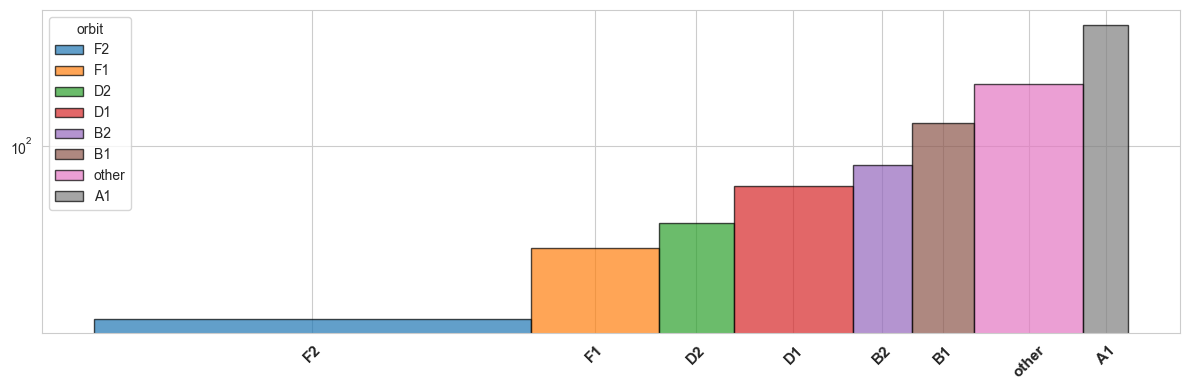

In [31]:
compact_op.plot(TARGET, 'share', log=True)
plt.tight_layout()
plt.show()

## RUN

#### Show Summary

\- Bar plot: mean lLTV by orbital (log scale)

## LOAD

\- Reload pipeline from saved artifacts  
by load the saved polyforest + compact rule.

In [33]:
rule_extractor_pipeline = RuleExtractorPipeline(project_path=PROJECT_PATH)
rule_extractor_pipeline.load_rule(
    rel_path_to_polyforest=f'/artifacts/learning/info/polynomial_form/{LOCATION}.yaml',
    rel_path_to_compact_op=f'/artifacts/learning/info/compact/{LOCATION}.yaml'
)

Rule(_assign_label=<bound method BaseCompactOperator.assign_label of <src.table.compact.simple_compact.SimpleCompactOperator object at 0x11c00c7d0>>, _labels=['out', 'F2', 'F1', 'D2', 'D1', 'B2', 'B1', 'A1', 'other'], _result_col='orbit')

# 3. Orbital Evaluation over Time (Stream)

\- Define anchor timestamps for temporal evaluation

In [34]:
execution_date = pd.to_datetime('2025-03-12')
anchor_timestamps = [execution_date + pd.Timedelta(i, 'W') for i in range(-5, 9)]
len(anchor_timestamps), anchor_timestamps[0], anchor_timestamps[-1]

(14, Timestamp('2025-02-05 00:00:00'), Timestamp('2025-05-07 00:00:00'))

In [35]:
np.random.seed(RANDOM_SEED)

users = session_processor.get_users_sample()
anchor_sample_users = np.random.choice(users, size=users.size // 10, replace=False)
anchor_sample_users

array([693092, 436711, 730346, ..., 605479, 450830, 100859],
      shape=(82946,))

In [36]:
rule_extractor_pipeline.rule

Rule(_assign_label=<bound method BaseCompactOperator.assign_label of <src.table.compact.simple_compact.SimpleCompactOperator object at 0x11c00c7d0>>, _labels=['out', 'F2', 'F1', 'D2', 'D1', 'B2', 'B1', 'A1', 'other'], _result_col='orbit')

\- Initialize OrbitalProcessor  
Combines feature extraction + orbital rule application + V_c estimation.  
STREAM_DIRNAME controls where per-timestamp labeled data is saved.

In [ ]:
# TODO: create directories:
#  'projects/<project_name>/artifacts/evaluation/stream/<data|potentials>/{STREAM_DIRNAME}'
STREAM_DIRNAME = 'sample-0.1' 


stream_extractor = FeatureExtractor(
    session_processor = session_processor,
    feature_rules = [cmplx_feature_rule],
    target_rule = m_target_rule
)

orbital_processor = OrbitalProcessor(
    feature_extractor=stream_extractor,
    rule=rule_extractor_pipeline.rule,
    dirname=STREAM_DIRNAME,
    project_path=PROJECT_PATH,
)

## 3.1 Orbital Labelling

Run full evaluation: features + target + orbital labels  
For each anchor timestamps and sampled users:
1. Extract 30-day lookback features
2. Extract 30-day forward target (gmv_target)
3. Apply orbital rule → assign each user to an orbital


Result: ~1.16M rows (83K users × 14 timestamps) with orbital labels.

In [38]:
orbital_processor.evaluate(
    timestamps=anchor_timestamps,        # (..., ts] & (ts, ...]
    users=anchor_sample_users,           # None (default) ~ all users
    with_target=True,                    # (default)
    verbose=True,
)

✔ : Extract Data: 557.465s
✔ : Label Data: 128.812s


frequency_0  recency_0        gmv_0  search_0  cat_0  \
timestamp  user_id                                                         
2025-02-05 693092           NaN        NaN          NaN       NaN    NaN   
           436711           NaN        NaN          NaN       NaN    NaN   
           730346          13.0       27.0    86.845503      13.0    1.0   
           478539           1.0       11.0     0.000000       0.0    1.0   
           654367          18.0       30.0  1592.774219      15.0   11.0   
...                         ...        ...          ...       ...    ...   
2025-05-07 505654           NaN        NaN          NaN       NaN    NaN   
           440168           3.0       26.0    52.486140       3.0    0.0   
           605479           NaN        NaN          NaN       NaN    NaN   
           450830           4.0       17.0     0.000000       2.0    2.0   
           100859           NaN        NaN          NaN       NaN    NaN   

                    has_to_cart_0  has_to_ord_0  to_cart_0  to_ord_0  \
timestamp  user_id                                                     
2025-02-05 693092             NaN           NaN        NaN       NaN   
           436711             NaN           NaN        NaN       NaN   
           730346             7.0           4.0       19.0      11.0   
           478539             0.0           0.0        0.0       0.0   
           654367             5.0           4.0        7.0       4.0   
...                           ...           ...        ...       ...   
2025-05-07 505654             NaN           NaN        NaN       NaN   
           440168             1.0           1.0        1.0       1.0   
           605479             NaN           NaN        NaN       NaN   
           450830             2.0           0.0        4.0       0.0   
           100859             NaN           NaN        NaN       NaN   

                    gmv_target  orbit  
timestamp  user_id                     
2025-02-05 693092          NaN    out  
           436711    81.023263    out  
           730346   222.170050  other  
           478539          NaN     F2  
           654367     0.000000  other  
...                        ...    ...  
2025-05-07 505654          NaN    out  
           440168     0.000000     D2  
           605479     0.000000    out  
           450830     0.000000     F1  
           100859          NaN    out  

[1161244 rows x 11 columns]

### Save/Load checkpoint

In [39]:
# Save
orbital_processor.save_labeled_data()

# Load
labeled_data = orbital_processor.load_labeled_data()
labeled_data

Save to ./projects/main/artifacts/evaluation/stream/data/sample-0.1
Load from ./projects/main/artifacts/evaluation/stream/data/sample-0.1


frequency_0  recency_0      gmv_0  search_0  cat_0  \
timestamp  user_id                                                       
2025-02-05 693092           NaN        NaN        NaN       NaN    NaN   
           307169           0.0        NaN   0.000000       0.0    0.0   
           450768           9.0       23.0  51.906364       8.0    3.0   
           469427          15.0       27.0   9.107822      15.0    2.0   
           610671           1.0       16.0   0.000000       1.0    0.0   
...                         ...        ...        ...       ...    ...   
2025-05-07 187209           NaN        NaN        NaN       NaN    NaN   
           669933           0.0        NaN   0.000000       0.0    0.0   
           602974           NaN        NaN        NaN       NaN    NaN   
           816360           NaN        NaN        NaN       NaN    NaN   
           100859           NaN        NaN        NaN       NaN    NaN   

                    has_to_cart_0  has_to_ord_0  to_cart_0  to_ord_0  \
timestamp  user_id                                                     
2025-02-05 693092             NaN           NaN        NaN       NaN   
           307169             0.0           0.0        0.0       0.0   
           450768             4.0           2.0        6.0       2.0   
           469427             6.0           1.0       13.0       1.0   
           610671             1.0           0.0        1.0       0.0   
...                           ...           ...        ...       ...   
2025-05-07 187209             NaN           NaN        NaN       NaN   
           669933             0.0           0.0        0.0       0.0   
           602974             NaN           NaN        NaN       NaN   
           816360             NaN           NaN        NaN       NaN   
           100859             NaN           NaN        NaN       NaN   

                    gmv_target orbit  
timestamp  user_id                    
2025-02-05 693092          NaN   out  
           307169          0.0   out  
           450768          0.0    B1  
           469427          0.0    D1  
           610671          NaN    F2  
...                        ...   ...  
2025-05-07 187209          NaN   out  
           669933          0.0   out  
           602974          NaN   out  
           816360          0.0   out  
           100859          NaN   out  

[1161244 rows x 11 columns]

## 3.2 Orbital Potential Estimation

\- Estimate V_c: average lLTV per orbital  
Computes E[gmv_target | orbit = c] for each orbital c,  
pooled across all anchor timestamps.  
These are the orbital "potentials" (revenue multipliers) from the paper.

In [40]:
%%time
orbital_processor.estimate(TARGET)

CPU times: user 110 ms, sys: 2.61 ms, total: 112 ms
Wall time: 114 ms


orbit
out        4.172585
F2        17.090333
F1        35.543307
D2        48.231119
D1        68.003036
B2        81.720797
B1       132.737214
A1       384.537662
other    201.828216
Name: gmv_target, dtype: float64

### Save/Load checkpoint

Saved as YAML under `artifacts/evaluation/stream/potentials/`  
These estimates are used by experiment notebooks (aa_test, bnpl_test)  
to compute orbital-based uplift without retraining.

In [41]:
# Save
orbital_processor.save_hats()
# Load
hat_potentials = orbital_processor.load_hats()
hat_potentials

orbit
out        4.172585
F2        17.090333
F1        35.543307
D2        48.231119
D1        68.003036
B2        81.720797
B1       132.737214
A1       384.537662
other    201.828216
Name: gmv_target, dtype: float64

\- Bar plot: V_c by orbital (log scale)

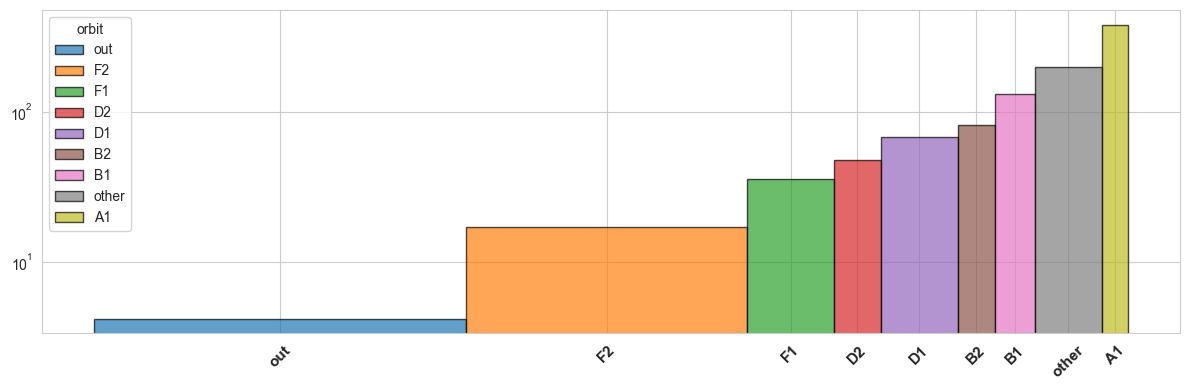

In [42]:
orbital_processor.stats.plot_bars(TARGET, log=True)
plt.tight_layout()
plt.show()